# Image Super Resolution with HuggingFace Diffusers

This notebook demonstrates how to perform **image super resolution** using the `stabilityai/stable-diffusion-x4-upscaler` model from HuggingFace Diffusers.

Super resolution is the task of upscaling a low-resolution image to a high-resolution version while recovering fine details. This is particularly useful in:
- Surveillance systems (e.g., license plate recognition)
- Medical imaging
- Satellite imagery enhancement
- Photo restoration

## What you'll learn
- How to load and use a diffusion-based super resolution pipeline
- How to upscale images using text-guided diffusion
- How to visualize and compare LR vs SR results

## Requirements
- A free Google Colab GPU (T4 is sufficient)
- HuggingFace `diffusers` library

In [1]:
#ll required libraries
!pip install -q diffusers transformers accelerate torch torchvision Pillow requests

In [2]:
import torch
from diffusers import StableDiffusionUpscalePipeline
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Load the super resolution pipeline
model_id = "stabilityai/stable-diffusion-x4-upscaler"
pipeline = StableDiffusionUpscalePipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")
print("Model loaded successfully!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/485 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stabilityai--stable-diffusion-x4-upscaler/snapshots/572c99286543a273bfd17fac263db5a77be12c4c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

Low-res image size: (128, 128)


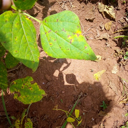

In [3]:
from datasets import load_dataset

# Load a sample image from HuggingFace datasets
dataset = load_dataset("beans", split="train[:1]")
low_res_img = dataset[0]["image"].convert("RGB")
low_res_img = low_res_img.resize((128, 128))
print(f"Low-res image size: {low_res_img.size}")
low_res_img

### 💡 Prompt & Hyperparameter Guide

The prompt plays an important role in guiding the upscaling process for the SD X4 Upscaler.

**Recommended prompt style:**
- Use quality-focused descriptions like `"a high quality, sharp photograph"`
- Keep it simple — the model's main job is upscaling, not content generation
- Avoid overly complex or scene-specific prompts

**Key hyperparameters to tune:**
- `num_inference_steps` (default: 20–75): Higher values produce finer details but take longer
- `guidance_scale` (default: 0–9): Controls how strongly the prompt influences the output. A value of `0` ignores the prompt entirely
- `noise_level` (default: 20): Amount of noise added to the low-res image before upscaling. Lower values preserve more of the original

In [4]:
# Run super resolution
prompt = "a high quality, sharp photograph"
upscaled_image = pipeline(
    prompt=prompt,
    image=low_res_img,
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

print(f"Upscaled image size: {upscaled_image.size}")

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion/pipeline_stable_diffusion_upscale.py:528: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


Upscaled image size: (512, 512)


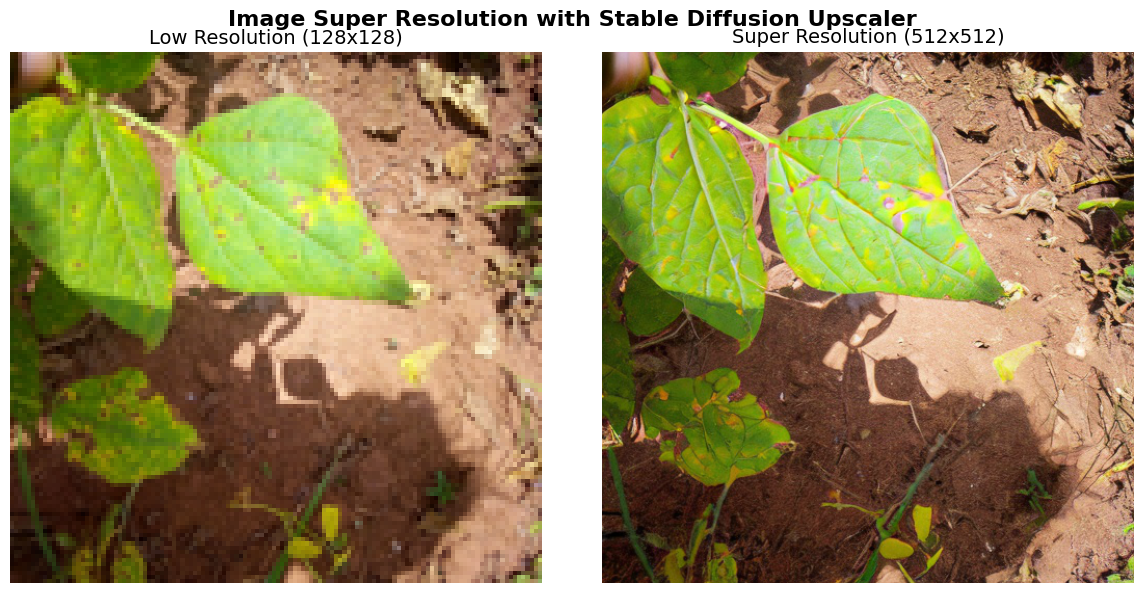

Saved comparison to sr_comparison.png


In [5]:
# Compare LR vs SR
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(low_res_img)
axes[0].set_title(f"Low Resolution ({low_res_img.size[0]}x{low_res_img.size[1]})", fontsize=14)
axes[0].axis("off")

axes[1].imshow(upscaled_image)
axes[1].set_title(f"Super Resolution ({upscaled_image.size[0]}x{upscaled_image.size[1]})", fontsize=14)
axes[1].axis("off")

plt.suptitle("Image Super Resolution with Stable Diffusion Upscaler", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("sr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved comparison to sr_comparison.png")